In [1]:
import sys
import os
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import warnings
# Отключаем лишние предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Добавляем корень проекта в путь для корректного импорта модулей
sys.path.append(os.path.abspath('../../..'))

KeyboardInterrupt: 

In [2]:
from DL.models.rotate_net import RotateNet
from DL.models.cascade_net import CascadeNet
from DL.trainers.model_trainer import ModelTrainer
from DL.data.rotated_cyrillic_dataset import RotatedCyrillicDataset
from DL.losses.rotation_loss import angular_cosine_loss
from DL.visualization.plot_utils import plot_confusion_matrices
from DL.visualization.classic_gradcam import visualize_classic_gradcam

In [3]:
# Настройка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
# Инициализация датасетов: 60к на обучение, 15к на валидацию
# Используем маскимальный угол 150 градусов, как в оригинальной статье
train_dataset = RotatedCyrillicDataset(60000, seed=42, max_angle=150)
test_dataset = RotatedCyrillicDataset(15000, seed=999, max_angle=150)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Данные готовы. Классов: {len(train_dataset.char_to_idx)}")

Данные готовы. Классов: 33


In [5]:
# Загружаем конфигурацию RotateNet с 16 каналами (выдает 32 координаты)
config_path_rot = '../../../DL/configs/rotatenet/rotatenet_spatial_32.json'
with open(config_path_rot, 'r') as f:
    config_rot = json.load(f)

print("=== ЭТАП 1: Обучение RotateNet (32 координаты) ===")
rotatenet = RotateNet(config_rot).to(device)
optimizer_rot = torch.optim.Adam(rotatenet.parameters(), lr=1e-3)

# 20 эпох достаточно, чтобы Spatial Softmax научился находить центры масс штрихов
epochs_stage1 = 20
for epoch in range(epochs_stage1):
    rotatenet.train()
    running_loss = 0.0

    for batch in train_loader:
        # Извлекаем картинку и целевой вектор [sin, cos]
        images, _, targets = batch[0].to(device), batch[1].to(device), batch[2].to(device)

        optimizer_rot.zero_grad()

        # Предсказание sin/cos и вектора координат
        pred_sin_cos, _ = rotatenet(images)

        # Специальный лосс: 1 - cos(error) + штраф за выход за 150 градусов
        loss = angular_cosine_loss(pred_sin_cos, targets, limit_deg=150.0)

        loss.backward()
        optimizer_rot.step()

        running_loss += loss.item() * images.size(0)

    avg_loss = running_loss / len(train_dataset)
    print(f"Эпоха {epoch+1}/{epochs_stage1} | Angular Loss: {avg_loss:.4f}")

print("\nRotateNet обучен. Переходим к сборке Каскада.")

=== ЭТАП 1: Обучение RotateNet (32 координаты) ===
Эпоха 1/20 | Angular Loss: 0.4949
Эпоха 2/20 | Angular Loss: 0.3925
Эпоха 3/20 | Angular Loss: 0.3323
Эпоха 4/20 | Angular Loss: 0.3044
Эпоха 5/20 | Angular Loss: 0.2657
Эпоха 6/20 | Angular Loss: 0.2388
Эпоха 7/20 | Angular Loss: 0.2225
Эпоха 8/20 | Angular Loss: 0.2050
Эпоха 9/20 | Angular Loss: 0.1781
Эпоха 10/20 | Angular Loss: 0.1895
Эпоха 11/20 | Angular Loss: 0.1635
Эпоха 12/20 | Angular Loss: 0.1637
Эпоха 13/20 | Angular Loss: 0.1422
Эпоха 14/20 | Angular Loss: 0.1704
Эпоха 15/20 | Angular Loss: 0.1363
Эпоха 16/20 | Angular Loss: 0.2123
Эпоха 17/20 | Angular Loss: 0.4395
Эпоха 18/20 | Angular Loss: 0.3012
Эпоха 19/20 | Angular Loss: 0.1688
Эпоха 20/20 | Angular Loss: 0.1446

RotateNet обучен. Переходим к сборке Каскада.


In [6]:
with open('../../../DL/configs/lenet/lenet_8kb.json', 'r') as f:
    config_8kb = json.load(f)
config_8kb['num_classes'] = len(train_dataset.char_to_idx)

# Создаем модель: stn_iters=2 (двойное выравнивание), use_polar=True
cascade_model = CascadeNet(config_8kb, rotatenet, use_polar=True, stn_iters=2).to(device)

for param in cascade_model.rotatenet.parameters():
    param.requires_grad = True

optimizer_cascade = torch.optim.Adam([
    {'params': cascade_model.classifier.parameters(), 'lr': 1e-3},
    {'params': cascade_model.rotatenet.parameters(), 'lr': 5e-5}
])

trainer_cascade = ModelTrainer(
    cascade_model, optimizer_cascade, nn.CrossEntropyLoss(), device,
    use_background_loss=True, bg_loss_alpha=10.0, bg_loss_n=2
)

In [7]:
print("\n=== ЭТАП 2: Итеративный Каскад (Curriculum Learning) ===")
# === CURRICULUM LEARNING LOOP ===
epochs = 20
for epoch in range(1, epochs + 1):
    # Каждые 4 эпохи увеличиваем сложность на 30 градусов
    current_max_angle = min(30 + ((epoch - 1) // 4) * 30, 150)

    # Динамически обновляем угол в датасете обучения
    train_dataset.max_angle = current_max_angle

    print(f"Эпоха {epoch}/{epochs} | Текущий угол трейна: ±{current_max_angle}° (Тест: ±150°)")

    # Тренируем 1 эпоху
    train_metrics = trainer_cascade.train_epoch(train_loader)

    # Оцениваем всегда на 150 градусах
    val_metrics = trainer_cascade.evaluate(test_loader)

    print(f"Трейн Лосс: {train_metrics['loss']:.4f} | Точность: {train_metrics['acc']:.4f} | BG Лосс: {train_metrics['bg_loss']:.4f}")
    print(f"Валид Лосс: {val_metrics['loss']:.4f} | Точность: {val_metrics['acc']:.4f}\n")




=== ЭТАП 2: Итеративный Каскад (Curriculum Learning) ===
Эпоха 1/20 | Текущий угол трейна: ±30° (Тест: ±150°)


Трейн Лосс: 2.2191 | Точность: 0.4536 | BG Лосс: 0.3572
Валид Лосс: 3.1068 | Точность: 0.2858

Эпоха 2/20 | Текущий угол трейна: ±30° (Тест: ±150°)


Трейн Лосс: 0.5905 | Точность: 0.8726 | BG Лосс: 0.0000
Валид Лосс: 3.9168 | Точность: 0.3551

Эпоха 3/20 | Текущий угол трейна: ±30° (Тест: ±150°)


Трейн Лосс: 0.1561 | Точность: 0.9668 | BG Лосс: 0.0001
Валид Лосс: 4.6014 | Точность: 0.3855

Эпоха 4/20 | Текущий угол трейна: ±30° (Тест: ±150°)


Трейн Лосс: 0.0668 | Точность: 0.9861 | BG Лосс: 0.0001
Валид Лосс: 5.0287 | Точность: 0.4019

Эпоха 5/20 | Текущий угол трейна: ±60° (Тест: ±150°)


...

Трейн Лосс: 0.1761 | Точность: 0.9511 | BG Лосс: 0.0002
Валид Лосс: 0.4831 | Точность: 0.8867

Эпоха 17/20 | Текущий угол трейна: ±150° (Тест: ±150°)


Трейн Лосс: 0.3565 | Точность: 0.9048 | BG Лосс: 0.0001
Валид Лосс: 0.2830 | Точность: 0.9222

Эпоха 18/20 | Текущий угол трейна: ±150° (Тест: ±150°)


Трейн Лосс: 0.2614 | Точность: 0.9262 | BG Лосс: 0.0001
Валид Лосс: 0.2306 | Точность: 0.9350

Эпоха 19/20 | Текущий угол трейна: ±150° (Тест: ±150°)


Трейн Лосс: 0.2092 | Точность: 0.9401 | BG Лосс: 0.0000
Валид Лосс: 0.1857 | Точность: 0.9478

Эпоха 20/20 | Текущий угол трейна: ±150° (Тест: ±150°)


Трейн Лосс: 0.1685 | Точность: 0.9530 | BG Лосс: 0.0002
Валид Лосс: 0.1566 | Точность: 0.9559




Матрица ошибок Итеративного Каскада:


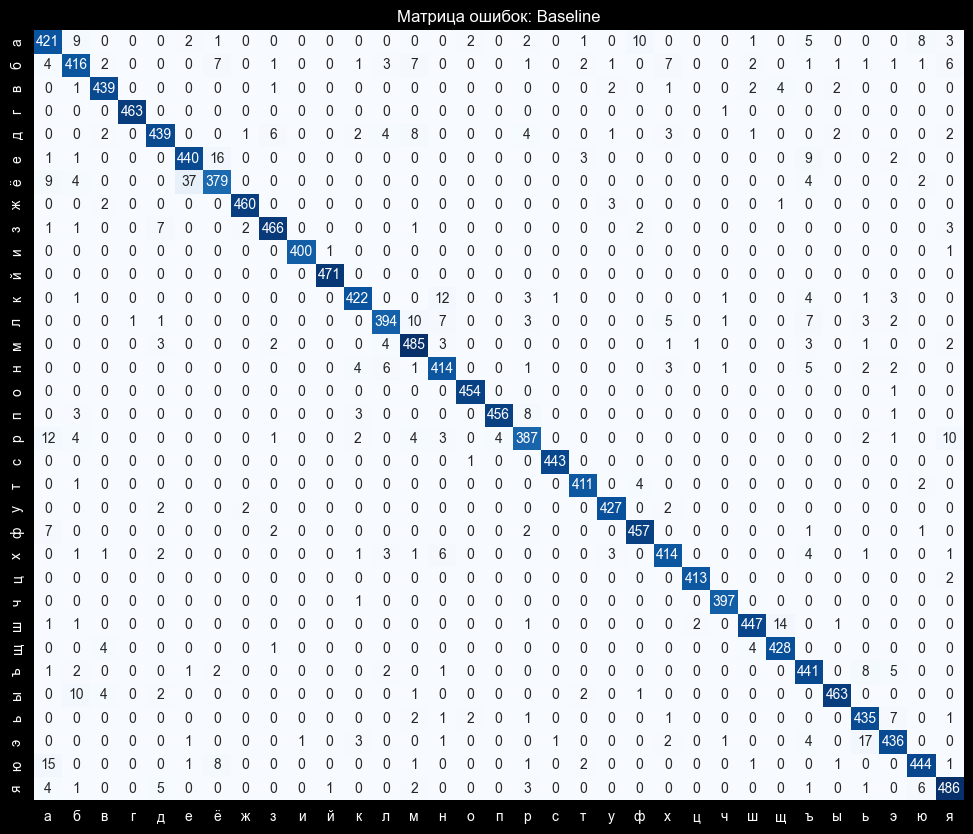

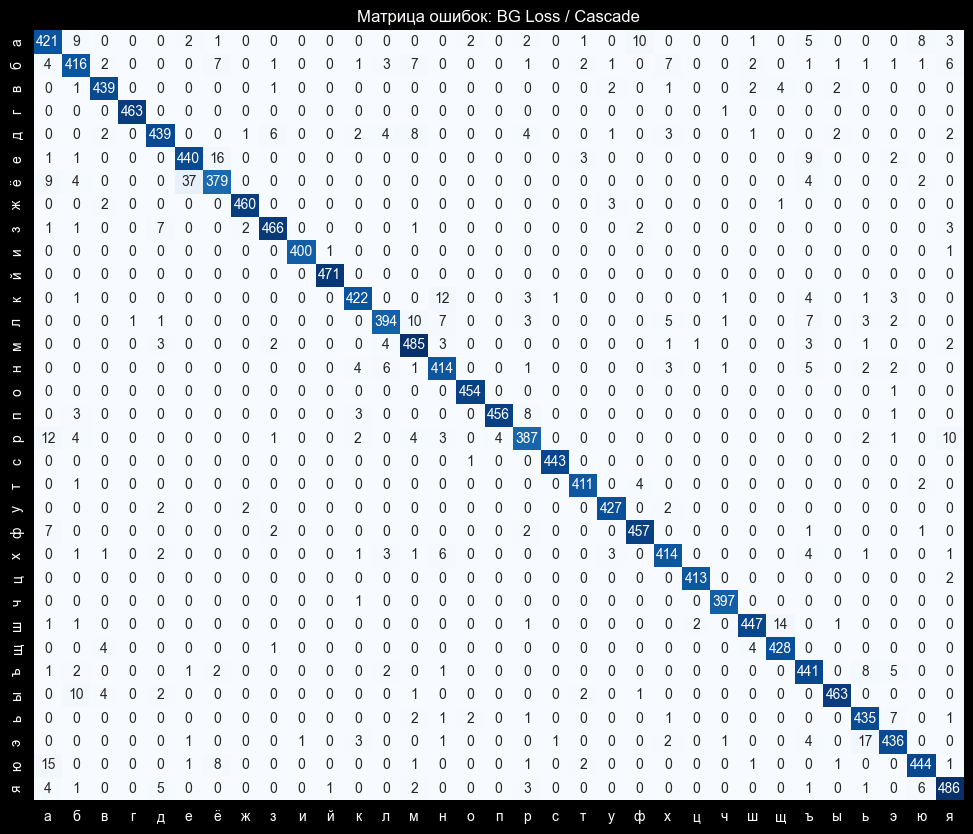

In [8]:
# Аналитика
print("\nМатрица ошибок Итеративного Каскада:")
plot_confusion_matrices(cascade_model, cascade_model, test_loader, test_dataset, device)

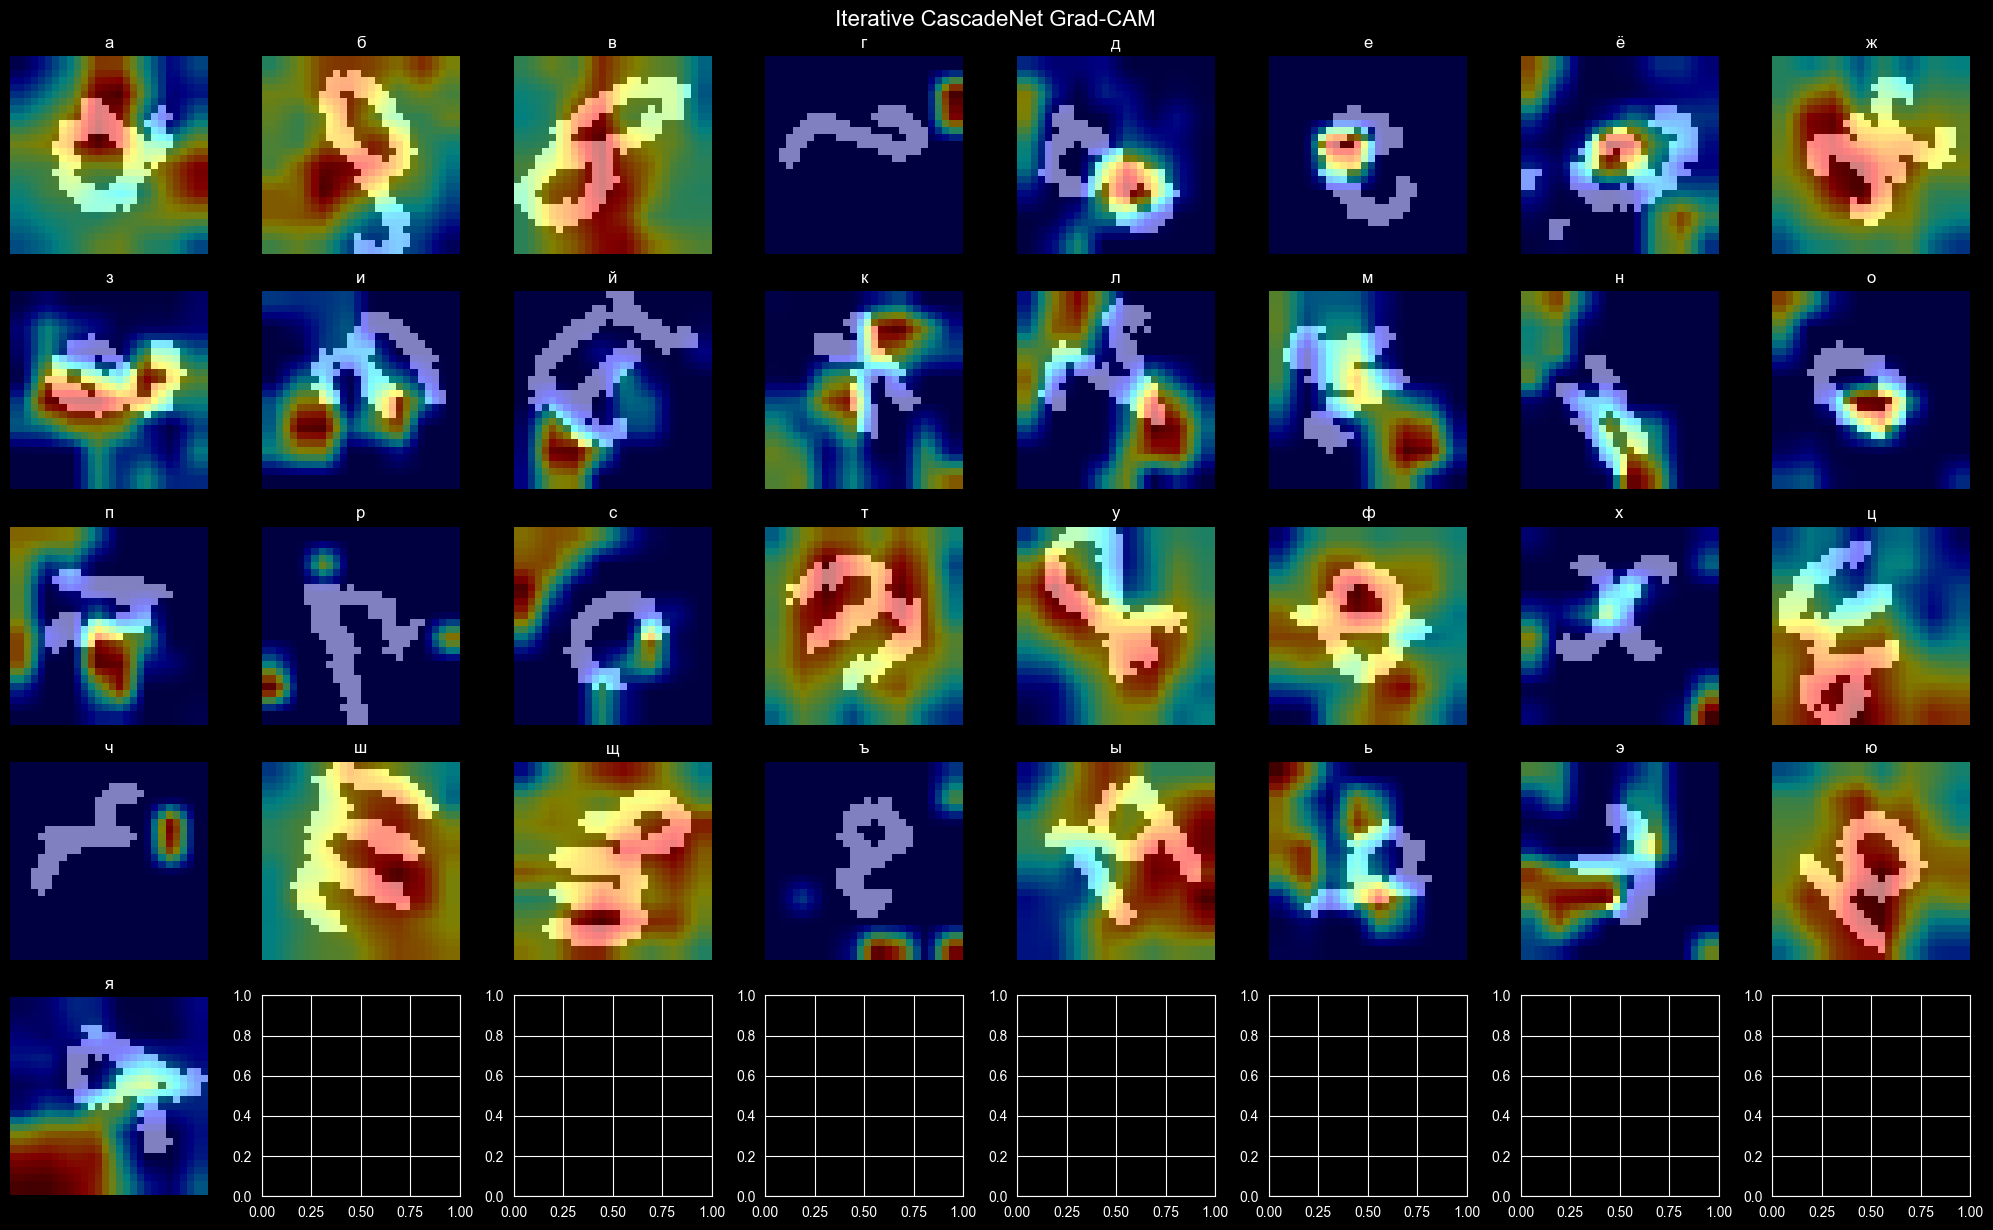

In [9]:
visualize_classic_gradcam(cascade_model, test_dataset, device, "Iterative CascadeNet Grad-CAM")
